In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle as pkl
from pathlib import Path
from collections import Counter

In [3]:
all_hvgs = []
for p in Path("./").glob("*.pkl"):
    with open(p, "rb") as f:
        hvgs = pkl.load(f)
        all_hvgs.extend(hvgs)

- For each gene, count the number of plates (h5ad files) in which it is selected as an HVG.

In [4]:
counts = Counter(all_hvgs)
counts.most_common(10)

[('GCLC', 14),
 ('CFTR', 14),
 ('KLHL13', 14),
 ('MTMR7', 14),
 ('SLC7A2', 14),
 ('CD38', 14),
 ('HSPB6', 14),
 ('PDK4', 14),
 ('THSD7A', 14),
 ('BAIAP2L1', 14)]

- HVG Frequency vs. Gene Count

In [5]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Count how many genes appear N times
count_freq = Counter(counts.values())   # {occur_times: n_genes}
sorted_freq = sorted(count_freq.items())
x = [k for k, v in sorted_freq]
y = [v for k, v in sorted_freq]

print("Occurrence count -> Number of genes:")
for k, v in sorted_freq:
    print(f"  {k} times: {v} genes")
print(f"\nTotal: {sum(y)} genes")

Occurrence count -> Number of genes:
  1 times: 5536 genes
  2 times: 3833 genes
  3 times: 2498 genes
  4 times: 1491 genes
  5 times: 772 genes
  6 times: 443 genes
  7 times: 310 genes
  8 times: 167 genes
  9 times: 150 genes
  10 times: 135 genes
  11 times: 130 genes
  12 times: 178 genes
  13 times: 278 genes
  14 times: 1674 genes

Total: 17595 genes


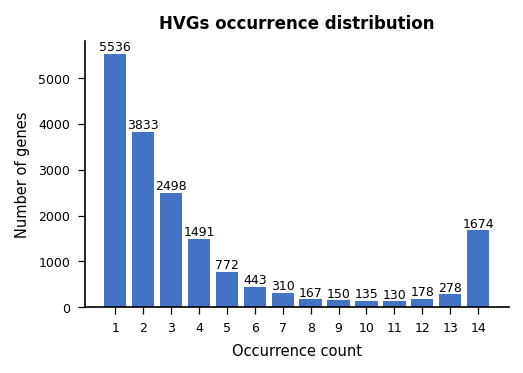

In [6]:
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "font.size": 7,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 0.8,
    "legend.frameon": False,
})

fig, ax = plt.subplots(figsize=(3.5, 2.5), dpi=150)

# Bar plot
bars = ax.bar(x, y, color='#4472C4', edgecolor='none', width=0.8)

# Labels
ax.set_xlabel('Occurrence count', fontsize=7)
ax.set_ylabel('Number of genes', fontsize=7)
ax.set_title('HVGs occurrence distribution', fontsize=8, fontweight='bold')

# Tick styling
ax.tick_params(axis='both', which='major', labelsize=6, width=0.6)
ax.set_xticks(x)

# Add value labels on bars
for bar, val in zip(bars, y):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', fontsize=6)

plt.tight_layout()
plt.show()

# # Save figure
# def save_pub_py(fig, filename, dpi=600):
#     fig.savefig(f"{filename}.svg", bbox_inches="tight")
#     fig.savefig(f"{filename}.pdf", bbox_inches="tight")
#     fig.savefig(f"{filename}.tiff", dpi=dpi, bbox_inches="tight")

# save_pub_py(fig, "hvg_occurrence_distribution")
# print("\nFigure saved: hvg_occurrence_distribution.{svg,pdf,tiff}")

- Merge and filter HVGs

In [7]:
# total
filtered_genes = []
for gene, count in counts.most_common():
    if count > 1:  # cutoff
        filtered_genes.append(gene)

filtered_genes = sorted(filtered_genes)
print(f"Number of genes kept in total: {len(filtered_genes)}")

with open(f"./merged_{len(filtered_genes)}_hvgs.pkl", "wb") as f:
    pkl.dump(filtered_genes, f)

Number of genes kept in total: 12059


In [8]:
# top2k
filtered_genes = []
for gene, count in counts.most_common(2000):
    filtered_genes.append(gene)

with open("./merged_2k_hvgs.pkl", "wb") as f:
    pkl.dump(filtered_genes, f)

In [9]:
# top5k
filtered_genes = []
for gene, count in counts.most_common(5000):
    filtered_genes.append(gene)

with open("./merged_5k_hvgs.pkl", "wb") as f:
    pkl.dump(filtered_genes, f)